# Carregar dados para a memória

In [1]:
import pandas as pd
from pathlib import Path

# Path to the directory

# df = pd.DataFrame()

# for file in files:
#     print(file.name)
#     aux_df = pd.read_csv(f"{directory_path}/{file.name}", sep=';')
#     df = pd.concat([df, aux_df])

df = pd.read_parquet("0.raw.parquet")
# df = pd.read_csv(f"HIST_PAINEL_COVIDBR_2020_Parte1_18abr2025.csv", sep=';')
df = df.reset_index()

len(df)

714481

### Linha do tempo

In [2]:
import seaborn as sns
import numpy as np
import matplotlib.dates
import matplotlib.pyplot as plt 
import locale

locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
plt.rcParams['axes.formatter.use_locale'] = True

def plot_comparacao_outliers_1(df1, label1=""):
    plt.figure(figsize=(20,5))
    df1['data'] = pd.to_datetime(df1['data'])
    plt.title(label1)
    sns.lineplot(data=df1, y="casosNovos", x='data')
    
    # Convert dates to matplotlib dates for proper tick placement
    dates = pd.to_datetime(df1['data'])
    mpl_dates = dates.map(matplotlib.dates.date2num)
    
    # Set major ticks every 3 months
    plt.gca().xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=1))
    
    # Format the date labels
    plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%B %Y'))
    
    # plt.xticks(rotation=90)
    plt.xlabel("")
    plt.ylabel("Casos novos", {'size': 14})

    plt.tick_params(axis='both', labelsize=14)


In [3]:
from sklearn.preprocessing import StandardScaler

def _remover_por_zscore(df):
    scaler = StandardScaler()
    LIMITE_COMUM = 1

    df["z_score"] = scaler.fit_transform(df[['casosNovos']])
    df_sem_outliers = df[abs(df["z_score"]) < LIMITE_COMUM]

    return df_sem_outliers

def _suavizar(df, window_size=7, threshold=2):
    """
    Smooth data by replacing outliers with previous day's casosNovos.
    Df must be indexed.
    
    Parameters:
    - df: pandas DataFrame with columns 'date' and 'casosNovos'
    - window_size: number of days to consider in rolling window
    - threshold: number of standard deviations to use for outlier detection
    
    Returns:
    - DataFrame with smoothed values
    """
    # Make a copy to avoid modifying original data
    df_smoothed = df.copy()
    
    # Calculate rolling statistics
    rolling_mean = df['casosNovos'].rolling(window=window_size, center=False, closed='left').mean()
    print(rolling_mean[window_size:])

    df_smoothed['casosNovos'] = pd.concat([df['casosNovos'][0:window_size], rolling_mean[window_size:]])

    return df_smoothed

7      114.000000
8      123.857143
9       70.428571
10      78.857143
11      79.571429
          ...    
122    380.142857
123    476.285714
124    474.142857
125    336.857143
126    354.142857
Name: casosNovos, Length: 118, dtype: float64


C:\Users\AlterUser\AppData\Local\Temp\ipykernel_71564\3478348279.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['data'] = pd.to_datetime(df1['data'])


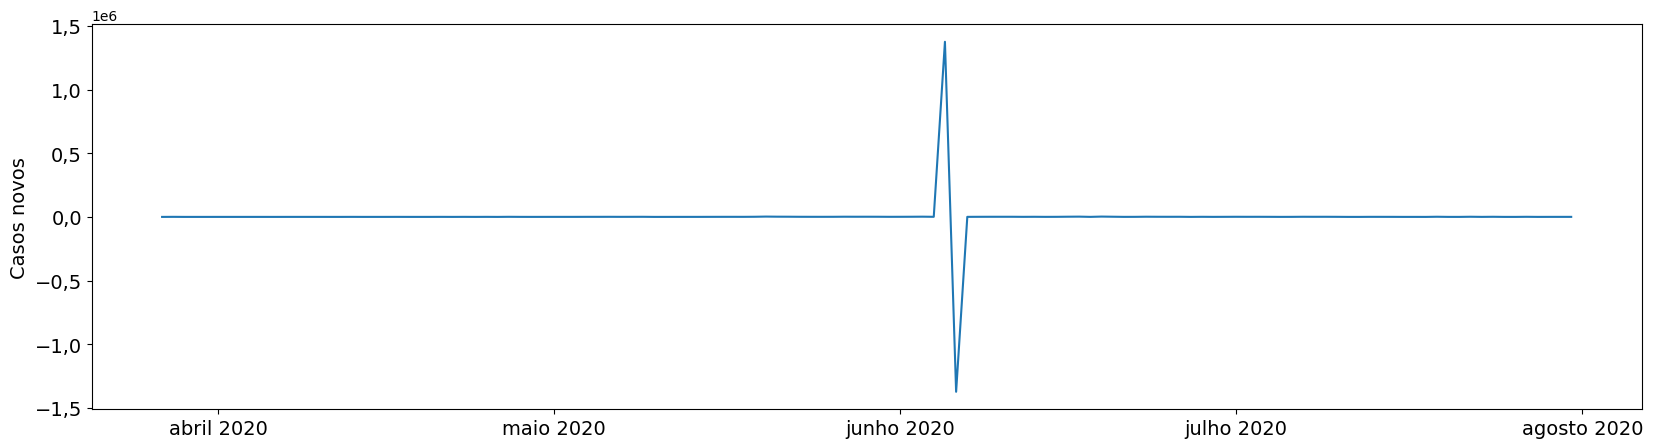

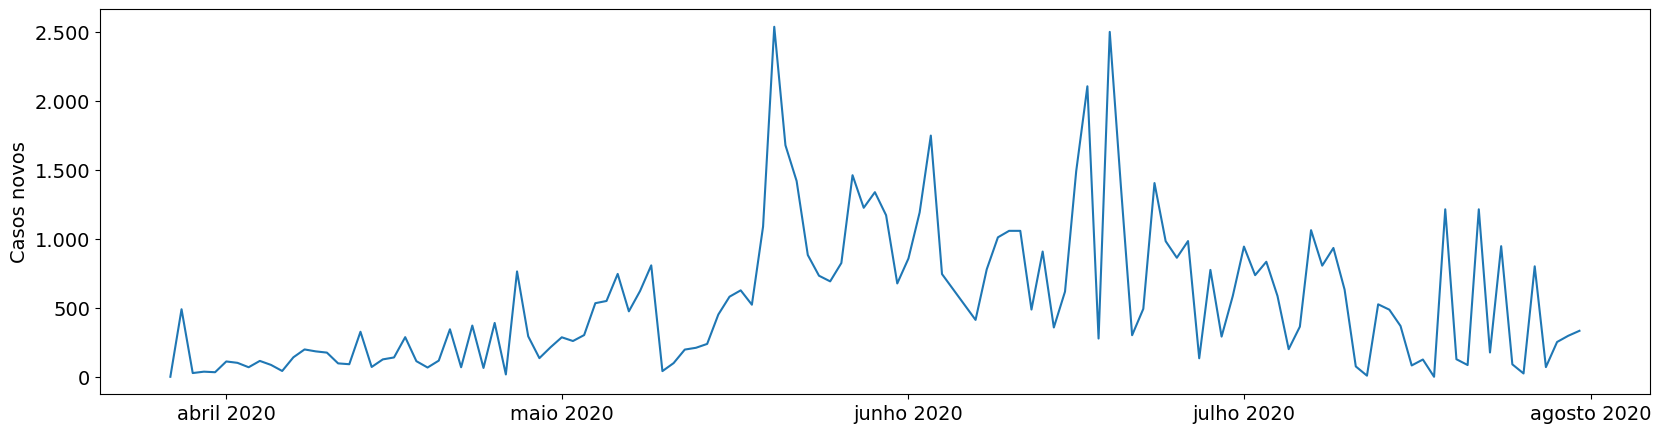

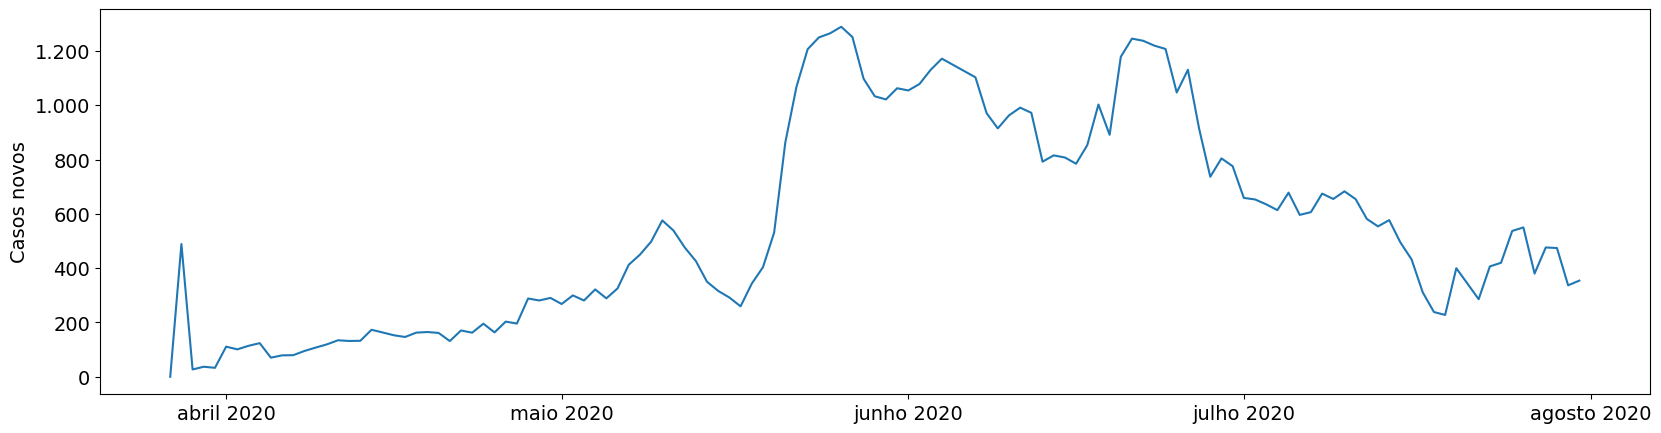

In [4]:
city_df = df[(df['municipio'] == 'Rio de Janeiro') & (df['estado'] == 'RJ')]
city_df = city_df.reset_index()

zscored_df = _remover_por_zscore(city_df)
smoothed_df = _suavizar(zscored_df, window_size=7)

plot_comparacao_outliers_1(city_df)
plot_comparacao_outliers_1(zscored_df)
plot_comparacao_outliers_1(smoothed_df)

7      114.000000
8      123.857143
9       70.428571
10      78.857143
11      79.571429
          ...    
122    380.142857
123    476.285714
124    474.142857
125    336.857143
126    354.142857
Name: casosNovos, Length: 120, dtype: float64


C:\Users\AlterUser\AppData\Local\Temp\ipykernel_71564\3478348279.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['data'] = pd.to_datetime(df1['data'])


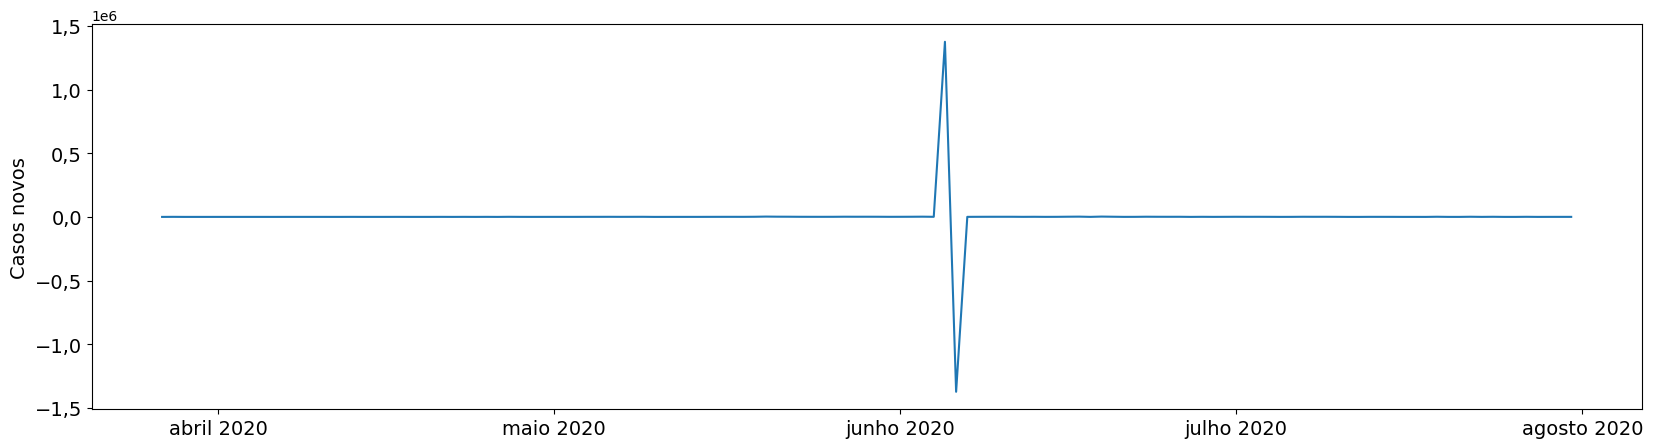

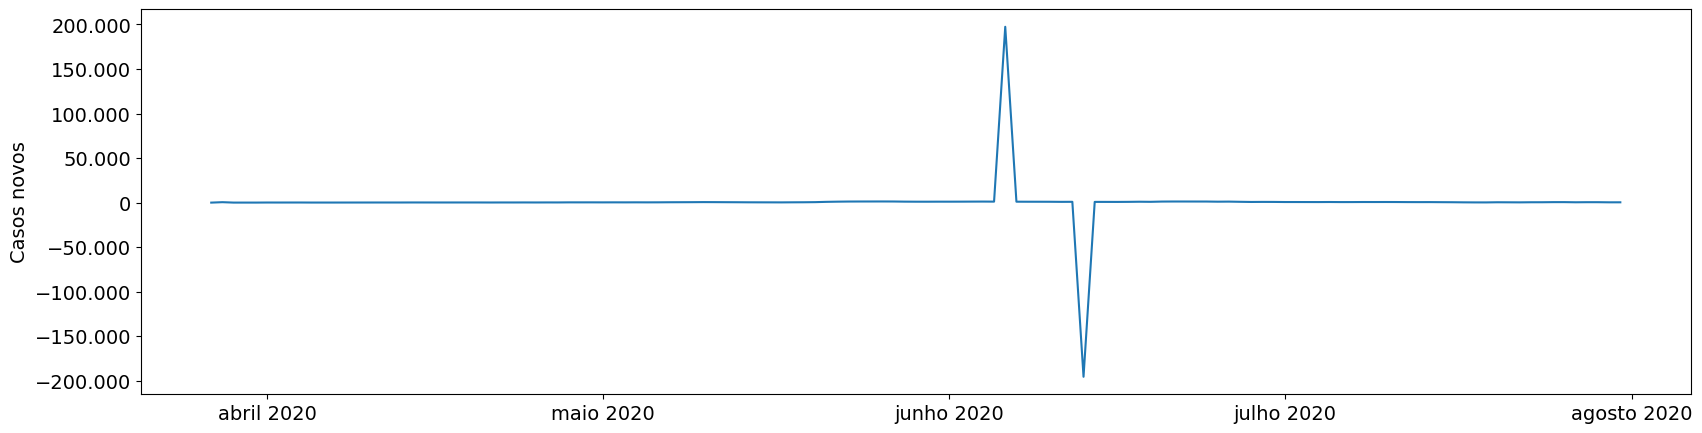

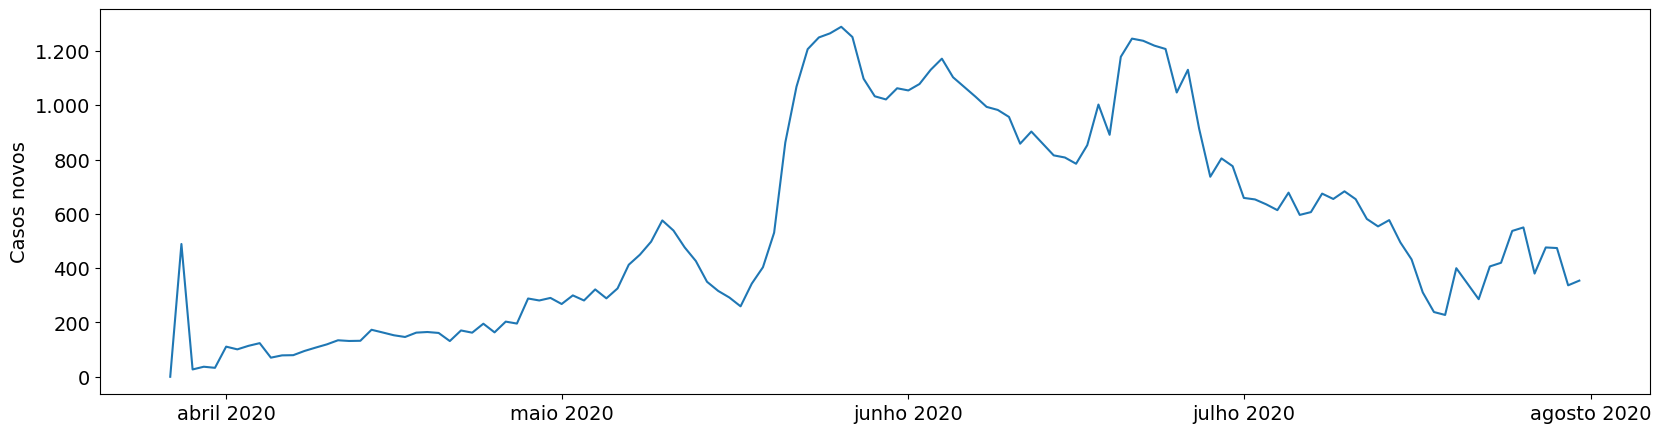

In [5]:
city_df = df[(df['municipio'] == 'Rio de Janeiro') & (df['estado'] == 'RJ')]
city_df = city_df.reset_index()

smoothed_df = _suavizar(city_df, window_size=7)
zscored_df = _remover_por_zscore(smoothed_df)

plot_comparacao_outliers_1(city_df)
plot_comparacao_outliers_1(smoothed_df)
plot_comparacao_outliers_1(zscored_df)